# Modellierung und Evaluation

In diesem Notebook werden verschiedene Machine-Learning-Modelle zur Vorhersage von Customer Churn trainiert und bewertet.

Zunächst werden die bereinigten Daten in Trainings- und Testdaten aufgeteilt. Anschließend werden modellabhängige Preprocessing-Schritte ausschließlich auf den Trainingsdaten gelernt, um Data Leakage zu vermeiden.

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report,
    RocCurveDisplay
)
from sklearn.ensemble import RandomForestClassifier

## Bereinigten Datensatz laden

In [49]:
df = pd.read_csv("../data/processed/iranian_churn_cleaned.csv")

df.shape

(2850, 13)

In [50]:
df.head()

,call_failure,complains,subscription_length,charge_amount,seconds_of_use,frequency_of_use,frequency_of_sms,distinct_called_numbers,tariff_plan,status,age,customer_value,churn
0,8,0,38,0,4370,71,5,17,1,1,30,197.640,0
1,0,0,39,0,318,5,7,4,1,2,25,46.035,0
2,10,0,37,0,2453,60,359,24,1,1,30,1536.520,0
3,10,0,38,0,4198,66,1,35,1,1,15,240.020,0
4,3,0,38,0,2393,58,2,33,1,1,15,145.805,0


## Features und Zielvariable definieren

In [51]:
X = df.drop(columns=["churn"])
y = df["churn"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (2850, 12)
Target: (2850,)


## Train/Test Split

Der Datensatz wird in Trainings- und Testdaten aufgeteilt. Die Trainingsdaten werden verwendet, um die Modelle und Preprocessing-Schritte zu lernen. Die Testdaten bleiben während des Trainings unberührt und dienen anschließend zur Bewertung der Generalisierungsfähigkeit.

Aufgrund des Klassenungleichgewichts wird die Zielvariable beim Split stratifiziert, sodass das Verhältnis von Churn- und Non-Churn-Fällen in Trainings- und Testdaten möglichst ähnlich bleibt.

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [53]:
print("Trainingsdaten:")
print(X_train.shape, y_train.shape)

print("\nTestdaten:")
print(X_test.shape, y_test.shape)

Trainingsdaten:
(2280, 12) (2280,)

Testdaten:
(570, 12) (570,)


In [54]:
print("Churn-Verteilung Training (%):")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nChurn-Verteilung Test (%):")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Churn-Verteilung Training (%):
churn
0    84.34
1    15.66
Name: proportion, dtype: float64

Churn-Verteilung Test (%):
churn
0    84.39
1    15.61
Name: proportion, dtype: float64


In [55]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTrain-Verteilung:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTest-Verteilung:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

X_train: (2280, 12)
X_test: (570, 12)

Train-Verteilung:
churn
0    84.34
1    15.66
Name: proportion, dtype: float64

Test-Verteilung:
churn
0    84.39
1    15.61
Name: proportion, dtype: float64


## Logistic Regression

Für die Logistic Regression werden numerische Features standardisiert und kategoriale Features mittels One-Hot-Encoding transformiert.

Das Preprocessing und das Modell werden in einer gemeinsamen Pipeline kombiniert. Dadurch werden die Transformationen ausschließlich auf den Trainingsdaten gelernt und anschließend identisch auf die Testdaten angewendet.

In [56]:
numeric_features = [
    "call_failure",
    "subscription_length",
    "charge_amount",
    "seconds_of_use",
    "frequency_of_use",
    "frequency_of_sms",
    "distinct_called_numbers",
    "customer_value"
]

categorical_features = [
    "complains",
    "tariff_plan",
    "status",
    "age"
]

In [57]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [58]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [59]:
logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['call_failure','complains','subscription_length',...,'status','age', 'customer_value']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder=

In [60]:
y_pred_logistic = logistic_pipeline.predict(X_test)

In [61]:
y_prob_logistic = logistic_pipeline.predict_proba(X_test)[:, 1]

In [62]:
print("Anzahl Vorhersagen:", len(y_pred_logistic))
print("Erste 10 Vorhersagen:", y_pred_logistic[:10])
print("Erste 10 Churn-Wahrscheinlichkeiten:", y_prob_logistic[:10].round(3))

Anzahl Vorhersagen: 570
Erste 10 Vorhersagen: [0 0 0 0 0 0 0 0 0 0]
Erste 10 Churn-Wahrscheinlichkeiten: [0.372 0.029 0.037 0.022 0.227 0.011 0.268 0.003 0.169 0.366]


## Evaluation der Logistic Regression

Zur Bewertung des Modells werden mehrere Metriken verwendet. Aufgrund des Klassenungleichgewichts wird die Modellleistung nicht ausschließlich anhand der Accuracy beurteilt.

In [63]:
accuracy_logistic = accuracy_score(y_test, y_pred_logistic)
precision_logistic = precision_score(y_test, y_pred_logistic)
recall_logistic = recall_score(y_test, y_pred_logistic)
f1_logistic = f1_score(y_test, y_pred_logistic)
roc_auc_logistic = roc_auc_score(y_test, y_prob_logistic)

print(f"Accuracy:  {accuracy_logistic:.3f}")
print(f"Precision: {precision_logistic:.3f}")
print(f"Recall:    {recall_logistic:.3f}")
print(f"F1-Score:  {f1_logistic:.3f}")
print(f"ROC-AUC:   {roc_auc_logistic:.3f}")

Accuracy:  0.902
Precision: 0.824
Recall:    0.472
F1-Score:  0.600
ROC-AUC:   0.928


In [64]:
print(classification_report(y_test, y_pred_logistic))

              precision    recall  f1-score   support

           0       0.91      0.98      0.94       481
           1       0.82      0.47      0.60        89

    accuracy                           0.90       570
   macro avg       0.87      0.73      0.77       570
weighted avg       0.90      0.90      0.89       570



### Confusion Matrix

In [65]:
cm_logistic = confusion_matrix(y_test, y_pred_logistic)

cm_logistic

array([[472,   9],
       [ 47,  42]])

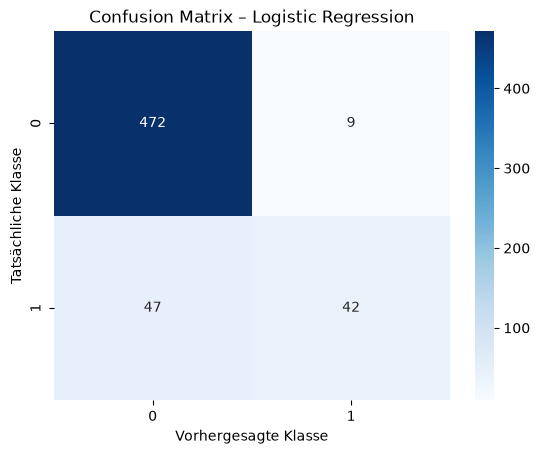

In [66]:
sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix – Logistic Regression")
plt.xlabel("Vorhergesagte Klasse")
plt.ylabel("Tatsächliche Klasse")
plt.show()

### ROC-Kurve

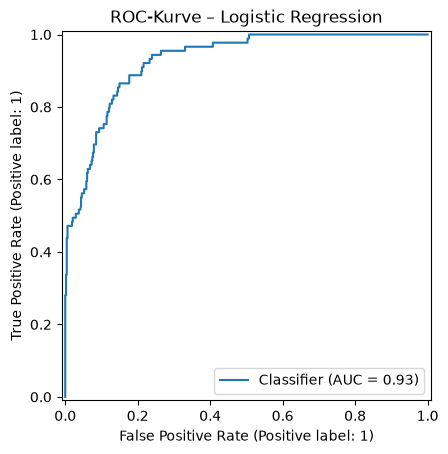

In [67]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob_logistic
)

plt.title("ROC-Kurve – Logistic Regression")
plt.show()

### Interpretation der Logistic Regression

Die Logistic Regression erreicht auf den Testdaten eine Accuracy von 90,2 %. Da die Churn-Klasse jedoch deutlich seltener auftritt, reicht die Accuracy allein nicht zur Bewertung des Modells aus.

Die Precision für die Churn-Klasse liegt bei 82,4 %. Damit sind die meisten Kunden, die vom Modell als Churn-Risiko erkannt werden, tatsächlich Churn-Fälle.

Der Recall beträgt dagegen nur 47,2 %. Von 89 tatsächlichen Churn-Fällen erkennt das Modell 42 korrekt, während 47 Churn-Kunden nicht erkannt werden. Für ein Retention-Szenario stellt dies eine relevante Schwäche dar, da mehr als die Hälfte der tatsächlich abwandernden Kunden übersehen wird.

Der F1-Score von 0,600 spiegelt den Unterschied zwischen hoher Precision und vergleichsweise niedrigem Recall wider.

Mit einer ROC-AUC von 0,928 besitzt das Modell gleichzeitig eine hohe Fähigkeit, Churn- und Non-Churn-Kunden anhand der vorhergesagten Wahrscheinlichkeiten voneinander zu unterscheiden. Dies deutet darauf hin, dass der standardmäßig verwendete Klassifikationsschwellenwert von 0,5 nicht zwingend optimal für ein Churn-Retention-Szenario sein muss.

Für den weiteren Modellvergleich wird zunächst der Standardschwellenwert beibehalten. Nach dem Vergleich mit dem Random Forest kann geprüft werden, ob eine Anpassung des Schwellenwerts sinnvoll ist.

## Random Forest

Als zweites Modell wird ein Random Forest Classifier trainiert. Im Gegensatz zur Logistic Regression kann der Random Forest auch nichtlineare Zusammenhänge und Interaktionen zwischen Merkmalen erfassen.

Numerische Features werden für dieses Modell nicht standardisiert, da baumbasierte Modelle nicht von einer einheitlichen Skalierung der Eingangsvariablen abhängig sind. Kategoriale Merkmale werden weiterhin mittels One-Hot-Encoding transformiert.

In [68]:
rf_preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        (
            "cat",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [69]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", rf_preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [70]:
random_forest_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['call_failure','complains','subscription_length',...,'status','age', 'customer_value']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder=

In [71]:
y_pred_rf = random_forest_pipeline.predict(X_test)

In [72]:
y_prob_rf = random_forest_pipeline.predict_proba(X_test)[:, 1]

In [73]:
print("Anzahl Vorhersagen:", len(y_pred_rf))
print("Erste 10 Vorhersagen:", y_pred_rf[:10])
print("Erste 10 Churn-Wahrscheinlichkeiten:", y_prob_rf[:10].round(3))

Anzahl Vorhersagen: 570
Erste 10 Vorhersagen: [1 0 0 0 0 0 0 0 1 0]
Erste 10 Churn-Wahrscheinlichkeiten: [0.69  0.    0.07  0.    0.4   0.    0.35  0.    0.78  0.325]
